In [ ]:
!pip install tensorflow

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

from PIL import Image
import pathlib


In [2]:
# getting the images 
imageDir = "./ocular-disease-recognition-odir5k/ODIR-5k/ODIR-5k/"
trainPathJoin = os.path.join(imageDir, 'Training_Images/')
trainImageDir = pathlib.Path(trainPathJoin).with_suffix('')
testPathJoin = os.path.join(imageDir, 'TestingImages/')
testImageDir = pathlib.Path(testPathJoin).with_suffix('')


In [3]:
data = pd.read_excel('Processed_data.xlsx')

In [4]:
newData = data.drop(['Patient ID','Patient Age', 'Patient Sex'], axis=1)
newData.head()

,Filename,Diagnosis,N,D,G,C,A,H,M,O
0,0_left.jpg,cataract,0,0,0,1,0,0,0,0
1,1_left.jpg,normal fundus,1,0,0,0,0,0,0,0
2,2_left.jpg,"laser spot,moderate non proliferative retinopathy",0,1,0,0,0,0,0,1
3,3_left.jpg,normal fundus,1,0,0,0,0,0,0,0
4,4_left.jpg,macular epiretinal membrane,0,0,0,0,0,0,0,1


In [5]:
newData.shape

(7000, 10)

In [6]:
img_width = 300
img_height = 300

X = []

for i in tqdm(range(newData.shape[0])):
    path = trainPathJoin + newData['Filename'][i]
    img = image
    img = image.load_img(path, target_size=(img_width, img_height, 3))
    img = image.img_to_array(img)
    img = img/255.0
    X.append(img)

X = np.array(X)
X.shape

  0%|          | 0/7000 [00:00<?, ?it/s]100%|██████████| 7000/7000 [03:18<00:00, 35.19it/s]


(7000, 300, 300, 3)

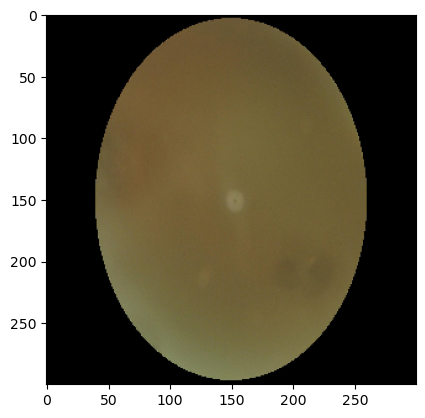

In [7]:
plt.imshow(X[0])

In [8]:
Y = data.drop(['Diagnosis','Patient ID','Patient Age', 'Patient Sex', 'Filename'], axis = 1)
Y = Y.to_numpy()
print(Y.shape)
Y

(7000, 8)


array([[0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state = 0, test_size = 0.15)

In [10]:
X_train[0].shape

(300, 300, 3)

In [11]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape = X_train[0].shape))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.4))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Dropout(0.5))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))


model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))


model.add(Dense(8, activation='sigmoid'))

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 298, 298, 16)      448       
                                                                 
 batch_normalization (BatchN  (None, 298, 298, 16)     64        
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 149, 149, 16)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 149, 149, 16)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 147, 147, 32)      4640      
                                                                 
 batch_normalization_1 (Batc  (None, 147, 147, 32)     1

In [13]:
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10


2023-11-18 15:03:02.678158: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


186/186 [==============================] - 191s 1s/step - loss: 0.7152 - accuracy: 0.1901 - val_loss: 0.4107 - val_accuracy: 0.3686
Epoch 2/10
186/186 [==============================] - 192s 1s/step - loss: 0.4053 - accuracy: 0.3783 - val_loss: 0.3393 - val_accuracy: 0.4619
Epoch 3/10
186/186 [==============================] - 184s 989ms/step - loss: 0.3503 - accuracy: 0.4247 - val_loss: 0.3300 - val_accuracy: 0.4619
Epoch 4/10
186/186 [==============================] - 238s 1s/step - loss: 0.3362 - accuracy: 0.4491 - val_loss: 0.3344 - val_accuracy: 0.4619
Epoch 5/10
186/186 [==============================] - 219s 1s/step - loss: 0.3305 - accuracy: 0.4492 - val_loss: 0.3172 - val_accuracy: 0.4619
Epoch 6/10
186/186 [==============================] - 202s 1s/step - loss: 0.3222 - accuracy: 0.4600 - val_loss: 0.3247 - val_accuracy: 0.4619
Epoch 7/10
186/186 [==============================] - 186s 998ms/step - loss: 0.3183 - accuracy: 0.4655 - val_loss: 0.3143 - val_accuracy: 0.4619
Epoc

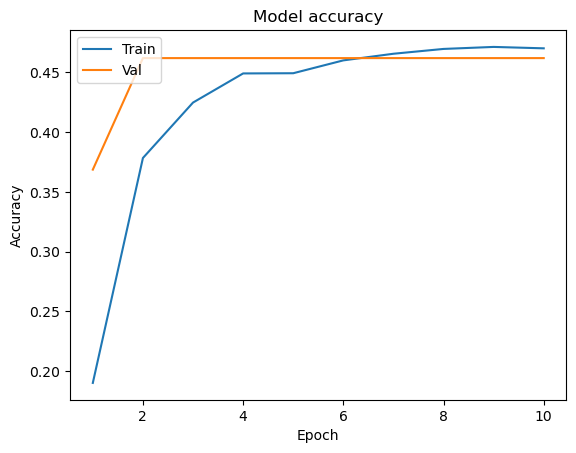

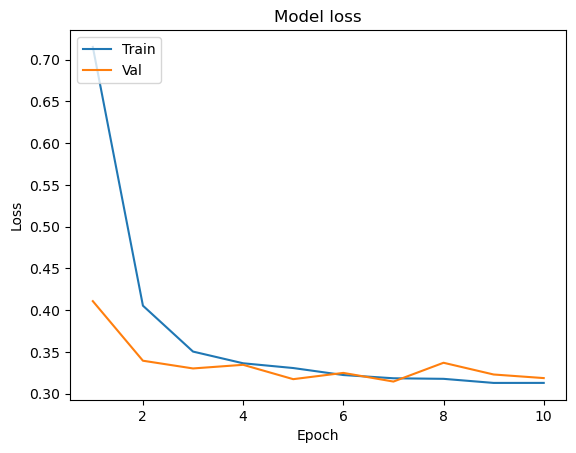

In [15]:
def plot_learningCurve(history, epoch):
  # Plot training & validation accuracy values
  epoch_range = range(1, epoch+1)
  plt.plot(epoch_range, history.history['accuracy'])
  plt.plot(epoch_range, history.history['val_accuracy'])
  plt.title('Model accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

  # Plot training & validation loss values
  plt.plot(epoch_range, history.history['loss'])
  plt.plot(epoch_range, history.history['val_loss'])
  plt.title('Model loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Val'], loc='upper left')
  plt.show()

plot_learningCurve(history, 10)

In [17]:
# Testing the model with the test image
testImageList = list(testImageDir.glob('*.jpg'))
image_count = len(testImageList)
classes = newData.columns[2:]

img = image.load_img(testImageList[0], target_size=(img_width, img_height, 3))
img = image.img_to_array(img)
img = img/255.0
img = img.reshape(1, img_width, img_height, 3)

y_prob = model.predict(img)
top3 = np.argsort(y_prob[0])[:-3:-1]

for i in range(2):
    print(classes[top3[i]])


1/1 [==============================] - 0s 26ms/step
N
D
